In [12]:
import pandas as pd
import numpy as np

# Recharger le dataset original
df = pd.read_csv(r"C:\Users\HP\Jupyter file\churn-prediction\data\Telco-Customer-Churn.csv", index_col="customerID")

print("📊 AVANT NETTOYAGE")
print(f"Dimensions: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\n")

📊 AVANT NETTOYAGE
Dimensions: (7043, 20)
Missing values: 0




In [4]:
# 1.1 Vérifier les types de données
print("="*60)
print("🔍 ÉTAPE 1: Diagnostic complet")
print("="*60)

print("\n📋 Types de données:")
print(df.dtypes)

print("\n⚠️ Valeurs manquantes par colonne:")
print(df.isnull().sum())

print("\n🎯 Valeurs uniques par colonne catégorielle:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} valeurs uniques")
    if df[col].nunique() < 10:
        print(f"   → {df[col].unique()[:5]}")

🔍 ÉTAPE 1: Diagnostic complet

📋 Types de données:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

⚠️ Valeurs manquantes par colonne:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperless

In [14]:
print("\n" + "="*60)
print("🔧 ÉTAPE 2: Nettoyage de TotalCharges (PIÈGE CLASSIQUE)")
print("="*60)

# 2.1 Vérifier ce qui ne va pas avec TotalCharges
print("\nAvant conversion:")
print(f"Type: {df['TotalCharges'].dtype}")
print(f"Exemples problématiques: {df[df['TotalCharges'].str.contains(' ', na=False)]['TotalCharges'].head()}")

# 2.2 Compter les valeurs problématiques (espaces vides)
problematic = df[df['TotalCharges'].str.strip() == '']
print(f"\nNombre de lignes avec TotalCharges vide: {len(problematic)}")

# 2.3 Convertir en numérique (forçant les erreurs en NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2.4 Vérifier les NaN créés
nan_count = df['TotalCharges'].isnull().sum()
print(f"Lignes devenues NaN après conversion: {nan_count}")

# 2.5 Décision: supprimer les NaN (peu nombreux)
if nan_count < 100:  # Moins de 2% des données
    df = df.dropna(subset=['TotalCharges'])
    print(f"✅ Lignes supprimées: {nan_count}")
    print(f"Nouvelle dimension: {df.shape}")
else:
    # Alternative: imputer par la moyenne
    df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])
    print(f"✅ NaN imputés par MonthlyCharges × tenure")


🔧 ÉTAPE 2: Nettoyage de TotalCharges (PIÈGE CLASSIQUE)

Avant conversion:
Type: object
Exemples problématiques: customerID
4472-LVYGI     
3115-CZMZD     
5709-LVOEQ     
4367-NUYAO     
1371-DWPAZ     
Name: TotalCharges, dtype: object

Nombre de lignes avec TotalCharges vide: 11
Lignes devenues NaN après conversion: 11
✅ Lignes supprimées: 11
Nouvelle dimension: (7032, 20)


In [16]:
print("\n" + "="*60)
print("🔧 ÉTAPE 3: Standardisation des catégories")
print("="*60)

# 3.1 Vérifier les espaces dans les valeurs
for col in df.select_dtypes(include='object').columns:
    if df[col].dtype == 'object':
        # Supprimer les espaces au début/fin
        df[col] = df[col].str.strip()
        
print("✅ Espaces supprimés")

# 3.2 Vérifier les catégories incohérentes
print("\nValeurs uniques par colonne clé:")
key_cols = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
for col in key_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


🔧 ÉTAPE 3: Standardisation des catégories
✅ Espaces supprimés

Valeurs uniques par colonne clé:

MultipleLines:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


In [18]:
print("\n" + "="*60)
print("🔧 ÉTAPE 4: Création de colonnes nettoyées")
print("="*60)

# 4.1 Convertir Yes/No en 0/1 pour les features binaires
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df[f'{col}_Num'] = df[col].map({'Yes': 1, 'No': 0})

print("✅ Colonnes binaires converties")

# 4.2 Traiter les valeurs 'No internet service' et 'No phone service'
# Ces valeurs sont équivalentes à 'No' pour la plupart des analyses
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    # Créer une version simplifiée
    df[f'{col}_Simplified'] = df[col].map({
        'Yes': 'Yes',
        'No': 'No',
        'No internet service': 'No'
    })
    # Version numérique
    df[f'{col}_Num'] = df[f'{col}_Simplified'].map({'Yes': 1, 'No': 0})

print("✅ Services internet standardisés")

# 4.3 Créer des groupes de tenure
df['Tenure_Group'] = pd.cut(df['tenure'], 
                             bins=[0, 1, 12, 24, 48, 72], 
                             labels=['<1 mois', '1-12 mois', '1-2 ans', '2-4 ans', '4-6 ans'])

print("✅ Groupes de tenure créés")

# 4.4 Créer une cible numérique
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Cible numérique créée")


🔧 ÉTAPE 4: Création de colonnes nettoyées
✅ Colonnes binaires converties
✅ Services internet standardisés
✅ Groupes de tenure créés
✅ Cible numérique créée


In [24]:
print("\n" + "="*60)
print("✅ ÉTAPE 5: Validation du nettoyage")
print("="*60)

# 5.1 Vérifier qu'il n'y a plus de NaN
print("\n1️⃣ Vérification des NaN:")
remaining_nulls = df.isnull().sum().sum()
if remaining_nulls == 0:
    print("✅ Plus AUCUNE valeur manquante!")
else:
    print(f"⚠️ Il reste {remaining_nulls} valeurs manquantes")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# 5.2 Vérifier que TotalCharges est maintenant numérique
print("\n2️⃣ Type de TotalCharges:")
print(f"Type: {df['TotalCharges'].dtype}")

# 5.3 Vérifier la plage des valeurs
print("\n3️⃣ Statistiques des variables numériques:")
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Num']
print(df[numeric_cols].describe())

# 5.4 Vérifier que les pourcentages sont cohérents
churn_rate = df['Churn_Num'].mean() * 100
print(f"\n4️⃣ Taux de churn: {churn_rate:.1f}%")

# 5.5 Vérifier les dimensions finales
print(f"\n5️⃣ Dimensions finales: {df.shape[0]} lignes, {df.shape[1]} colonnes")


✅ ÉTAPE 5: Validation du nettoyage

1️⃣ Vérification des NaN:
✅ Plus AUCUNE valeur manquante!

2️⃣ Type de TotalCharges:
Type: float64

3️⃣ Statistiques des variables numériques:
            tenure  MonthlyCharges  TotalCharges    Churn_Num
count  7032.000000     7032.000000   7032.000000  7032.000000
mean     32.421786       64.798208   2283.300441     0.265785
std      24.545260       30.085974   2266.771362     0.441782
min       1.000000       18.250000     18.800000     0.000000
25%       9.000000       35.587500    401.450000     0.000000
50%      29.000000       70.350000   1397.475000     0.000000
75%      55.000000       89.862500   3794.737500     1.000000
max      72.000000      118.750000   8684.800000     1.000000

4️⃣ Taux de churn: 26.6%

5️⃣ Dimensions finales: 7032 lignes, 38 colonnes


In [28]:
# Créer un dossier pour les données nettoyées si besoin
import os
os.makedirs('data/cleaned', exist_ok=True)

# Sauvegarder deux versions:

# Version 1: Complete (pour analyse avancée)
df.to_csv('data/cleaned/telco_cleaned_complete.csv', index=False)

# Version 2: Ready-to-use pour ML (seulement les colonnes utiles)
ml_columns = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
              'Partner_Num', 'Dependents_Num', 'PhoneService_Num', 'PaperlessBilling_Num',
              'OnlineSecurity_Num', 'OnlineBackup_Num', 'DeviceProtection_Num',
              'TechSupport_Num', 'StreamingTV_Num', 'StreamingMovies_Num',
              'Churn_Num']

# Ajouter les colonnes catégorielles encodées
# Pour Contract et InternetService, on utilisera get_dummies plus tard
# Pour l'instant, garder les versions originales

df_ml = df[ml_columns + ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'Tenure_Group']]
df_ml.to_csv('data/cleaned/telco_ready_for_ml.csv', index=False)

print("\n" + "="*60)
print("💾 Fichiers sauvegardés!")
print("="*60)
print("📁 data/cleaned/telco_cleaned_complete.csv - Toutes les colonnes")
print("📁 data/cleaned/telco_ready_for_ml.csv - Prêt pour le ML")


💾 Fichiers sauvegardés!
📁 data/cleaned/telco_cleaned_complete.csv - Toutes les colonnes
📁 data/cleaned/telco_ready_for_ml.csv - Prêt pour le ML


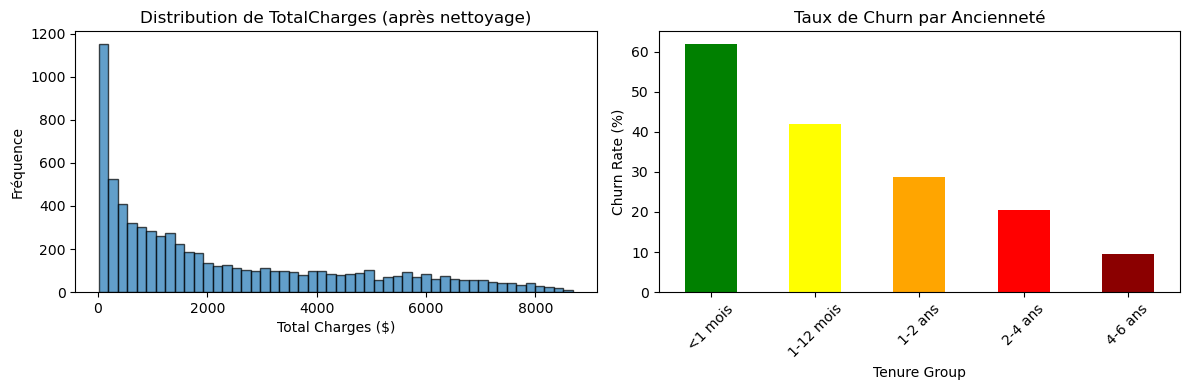

In [32]:
# Visualisation rapide pour confirmer que tout va bien
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution de TotalCharges
axes[0].hist(df['TotalCharges'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution de TotalCharges (après nettoyage)')
axes[0].set_xlabel('Total Charges ($)')
axes[0].set_ylabel('Fréquence')

# Taux de churn par groupe de tenure
tenure_churn = df.groupby('Tenure_Group')['Churn_Num'].mean() * 100
tenure_churn.plot(kind='bar', ax=axes[1], color=['green', 'yellow', 'orange', 'red', 'darkred'])
axes[1].set_title('Taux de Churn par Ancienneté')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Tenure Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [34]:
checklist = {
    "✅ TotalCharges converti en numérique": True,
    "✅ Pas de valeurs manquantes": df.isnull().sum().sum() == 0,
    "✅ Colonnes binaires converties en 0/1": 'Partner_Num' in df.columns,
    "✅ Groupe de tenure créé": 'Tenure_Group' in df.columns,
    "✅ Cible numérique créée": 'Churn_Num' in df.columns,
    "✅ Taux de churn cohérent (25-30%)": 25 < df['Churn_Num'].mean()*100 < 30
}

print("\n" + "="*60)
print("📋 CHECKLIST FINALE")
print("="*60)
for item, status in checklist.items():
    if status:
        print(f"✅ {item}")
    else:
        print(f"❌ {item} - À corriger!")


📋 CHECKLIST FINALE
✅ ✅ TotalCharges converti en numérique
✅ ✅ Pas de valeurs manquantes
✅ ✅ Colonnes binaires converties en 0/1
✅ ✅ Groupe de tenure créé
✅ ✅ Cible numérique créée
✅ ✅ Taux de churn cohérent (25-30%)
